## Midterm project - Cyberbullying prediction in Mongolia

This prediction model is based on a synthetic dataset generated based on the UNDP Cyberbullying report "Connecting with care: a survey on cyberbullying among Mongolian youth". The report was released in March 2025 and can be found [here](https://www.undp.org/sites/g/files/zskgke326/files/2025-08/undp_cyberbullying_report_eng_0.pdf).

## I. Analysing data and choosing the plan of actions

### 1 Dataset

In [89]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.tree import export_text
import seaborn as sns

In [2]:
df_s = pd.read_csv('./data/students_data.csv')

In [3]:
df_s

,id,type,age_group,gender,daily_internet_hours,primary_activity,uses_facebook,num_social_media_accounts,exposed_to_bad_language,learned_bad_words,experienced_cyberbullying,cyberbullying_types,reported_incident,reported_to,mental_health_impact,received_school_education,awareness_level,impact_certainty
0,S0001,Student,13-17,Male,1,Videos,True,4,True,True,True,Defamation; Sexual Harassment,False,NaN,Depression; Anxiety,True,Medium,Unsure
1,S0002,Student,13-17,Male,7,Chatting,True,1,True,True,False,NaN,NaN,NaN,NaN,False,Low,Not Applicable
2,S0003,Student,9-12,Female,0,Social Media,True,3,True,True,False,NaN,NaN,NaN,NaN,True,Medium,Not Applicable
3,S0004,Student,13-17,Female,2,Social Media,False,1,True,False,True,Insults; Defamation,False,NaN,Academic Decline; Anxiety,True,High,Unsure
4,S0005,Student,13-17,Female,6,Chatting,True,1,False,False,False,NaN,NaN,NaN,NaN,False,Low,Not Applicable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3807,S3808,Student,13-17,Female,2,Videos,False,1,False,False,True,Insults; Defamation,True,Teacher,NaN,False,Low,Unsure
3808,S3809,Student,13-17,Male,4,Studying,True,1,True,False,True,Defamation,True,Family,NaN,False,Medium,Unsure
3809,S3810,Student,9-12,Male,1,Chatting,False,1,False,False,False,NaN,NaN,NaN,NaN,False,Medium,Not Applicable
3810,S3811,Student,13-17,Female,1,Social Media,True,2,False,False,False,NaN,NaN,NaN,NaN,False,Medium,Not Applicable


In [4]:
# Dataset with data from parents
df_p = pd.read_csv('./data/parents_data.csv')
df_p

,id,type,age_group,internet_control,knows_facebook_age_req,aware_of_child_cyberbullying,concerns_about_device_use,digital_literacy,communicates_about_safety,child_age_group
0,P0001,Parent,35-44,Yes,False,Unsure,NaN,Low,False,13-17
1,P0002,Parent,45-54,Yes,True,Unsure,Insomnia; Academic Performance,Medium,True,9-12
2,P0003,Parent,45-54,Yes,True,No,Insomnia,High,True,13-17
3,P0004,Parent,45-54,Want to but struggle,True,No,Academic Performance; Depression,Low,True,9-12
4,P0005,Parent,25-34,Yes,False,Unsure,Academic Performance,Medium,True,9-12
...,...,...,...,...,...,...,...,...,...,...
1630,P1631,Parent,45-54,Yes,True,No,NaN,High,True,13-17
1631,P1632,Parent,45-54,Yes,False,No,Insomnia,Low,True,9-12
1632,P1633,Parent,45-54,Want to but struggle,True,Unsure,NaN,Low,False,13-17
1633,P1634,Parent,45-54,No,False,No,Academic Performance; Depression,Medium,True,13-17


### 2 EDA

In [5]:
# Checking content of columns for students
for col in df_s.columns:
    print(col)
    print(df_s[col].unique()[:5])
    print(df_s[col].nunique())
    print()

id
['S0001' 'S0002' 'S0003' 'S0004' 'S0005']
3812

type
['Student']
1

age_group
['13-17' '9-12']
2

gender
['Male' 'Female']
2

daily_internet_hours
[1 7 0 2 6]
9

primary_activity
['Videos' 'Chatting' 'Social Media' 'Gaming' 'Studying']
5

uses_facebook
[ True False]
2

num_social_media_accounts
[4 1 3 2]
4

exposed_to_bad_language
[ True False]
2

learned_bad_words
[ True False]
2

experienced_cyberbullying
[ True False]
2

cyberbullying_types
['Defamation; Sexual Harassment' nan 'Insults; Defamation'
 'Insults; Defamation; Exclusion' 'Insults']
30

reported_incident
[False nan True]
2

reported_to
[nan 'Family' 'Friend' 'School Counselor' 'Teacher']
4

mental_health_impact
['Depression; Anxiety' nan 'Academic Decline; Anxiety' 'Insomnia'
 'Depression']
31

received_school_education
[ True False]
2

awareness_level
['Medium' 'Low' 'High']
3

impact_certainty
['Unsure' 'Not Applicable' 'Certain']
3



In [6]:
# Checking content of columns for parents
for col in df_p.columns:
    print(col)
    print(df_p[col].unique()[:5])
    print(df_p[col].nunique())
    print()

id
['P0001' 'P0002' 'P0003' 'P0004' 'P0005']
1635

type
['Parent']
1

age_group
['35-44' '45-54' '25-34' '55+']
4

internet_control
['Yes' 'Want to but struggle' 'No']
3

knows_facebook_age_req
[False  True]
2

aware_of_child_cyberbullying
['Unsure' 'No' 'Yes']
3

concerns_about_device_use
[nan 'Insomnia; Academic Performance' 'Insomnia'
 'Academic Performance; Depression' 'Academic Performance']
30

digital_literacy
['Low' 'Medium' 'High']
3

communicates_about_safety
[False  True]
2

child_age_group
['13-17' '9-12']
2



In [7]:
# Analysing numerical values for students
df_s.describe()

,daily_internet_hours,num_social_media_accounts
count,3812.000000,3812.000000
mean,3.574502,1.646118
std,2.258884,1.046744
min,0.000000,1.000000
25%,2.000000,1.000000
50%,3.000000,1.000000
75%,5.000000,2.000000
max,8.000000,4.000000


In [8]:
# Analysing numerical values for parents
df_p.describe()

,id,type,age_group,internet_control,knows_facebook_age_req,aware_of_child_cyberbullying,concerns_about_device_use,digital_literacy,communicates_about_safety,child_age_group
count,1635,1635,1635,1635,1635,1635,1159,1635,1635,1635
unique,1635,1,4,3,2,3,30,3,2,2
top,P0001,Parent,35-44,Yes,True,No,Insomnia,Low,True,13-17
freq,1,1635,940,847,1006,989,210,743,869,1108


In [9]:
# Checking missing values for students
df_s.isnull().sum()

id                              0
type                            0
age_group                       0
gender                          0
daily_internet_hours            0
primary_activity                0
uses_facebook                   0
num_social_media_accounts       0
exposed_to_bad_language         0
learned_bad_words               0
experienced_cyberbullying       0
cyberbullying_types          2326
reported_incident            2074
reported_to                  2954
mental_health_impact         2611
received_school_education       0
awareness_level                 0
impact_certainty                0
dtype: int64

In [10]:
# Checking missing values for parents
df_p.isnull().sum()

id                                0
type                              0
age_group                         0
internet_control                  0
knows_facebook_age_req            0
aware_of_child_cyberbullying      0
concerns_about_device_use       476
digital_literacy                  0
communicates_about_safety         0
child_age_group                   0
dtype: int64

In [11]:
df_s.experienced_cyberbullying.value_counts()

experienced_cyberbullying
False    2074
True     1738
Name: count, dtype: int64

**Note:** Based on the count of values in experienced_cyberbullying, it can be said that all incidents has a label for reported_incident and most incidents have labels for other columns that contain missing variables. In fact, many of those variables are missing because they would not make sense since cyberbullying did not occur

In [12]:
# Student reality
student_cb_rate = df_s['experienced_cyberbullying'].mean()
print(f"Actual cyberbullying rate: {student_cb_rate:.1%}")

# Parent awareness
parent_aware_rate = (df_p['aware_of_child_cyberbullying'] == 'Yes').mean()
print(f"Parents who know: {parent_aware_rate:.1%}")

# The GAP is the insight!
print(f"Awareness gap: {student_cb_rate - parent_aware_rate:.1%}")

Actual cyberbullying rate: 45.6%
Parents who know: 3.4%
Awareness gap: 42.2%


Though there is data on both cyberbullying incidents and parents awareness, it is not possible to do accurate analyse of the effects parental control might have on the cyberbullying instances because the original data does not create parent-student pairs. Therefore, I will not use the dataset with information from parents in this model and focus mainly on predicting cyberbullying

### 3 Data cleaning

Many of the missing values are not there simply because they depend on another variable to be True. Below, I will use a script to introduce a new type Not applicable for such variables

In [13]:
# Function to process the Missing Not At Random values
def preprocess_cyberbullying_data(df):
    """
    Comprehensive preprocessing for cyberbullying dataset
    Returns two dataframes: df (all students, no missing values) and victims_df (only victims)
    """
    df = df.copy()

    # === 1. Handle conditional missingness - Fill original columns ===
    
    # Cyberbullying types: if not cyberbullied, mark as "Not Applicable"
    df['cyberbullying_types'] = df.apply(
        lambda row: 'Not Applicable' if not row['experienced_cyberbullying']
                    else (row['cyberbullying_types'] if pd.notna(row['cyberbullying_types']) 
                          else 'None'),
        axis=1
    )
    
    # Reported incident: if not cyberbullied, mark as "Not Applicable"
    df['reported_incident'] = df.apply(
        lambda row: 'Not Applicable' if not row['experienced_cyberbullying']
                    else ('Yes' if row['reported_incident'] == True
                          else 'No' if row['reported_incident'] == False
                          else 'Unknown'),
        axis=1
    )
    
    # Reported to: if not cyberbullied or didn't report, mark accordingly
    df['reported_to'] = df.apply(
        lambda row: 'Not Applicable' if not row['experienced_cyberbullying']
                    else ('Not Reported' if row['reported_incident'] in ['No', False]
                          else (row['reported_to'] if pd.notna(row['reported_to']) 
                                else 'Unknown')),
        axis=1
    )
    
    # Mental health impact: if not cyberbullied, mark as "Not Applicable"
    df['mental_health_impact'] = df.apply(
        lambda row: 'Not Applicable' if not row['experienced_cyberbullying']
                    else (row['mental_health_impact'] if pd.notna(row['mental_health_impact'])
                          else 'None'),
        axis=1
    )
    
    # Impact certainty: already handled in generation, but clean up any issues
    df['impact_certainty'] = df.apply(
        lambda row: 'Not Applicable' if not row['experienced_cyberbullying']
                    else (row['impact_certainty'] if pd.notna(row['impact_certainty'])
                          else 'Unsure'),
        axis=1
    )
    
    # === 2. Create additional categorical variable for reporting status ===
    df['reported_status'] = df.apply(
        lambda row: 'Not Applicable' if not row['experienced_cyberbullying']
                    else ('Reported' if row['reported_incident'] == 'Yes'
                          else 'Not Reported'),
        axis=1
    )
    
    # === 3. Extract useful numeric counts from multi-value fields ===
    # Cyberbullying types count
    df['num_bullying_types'] = df['cyberbullying_types'].apply(
        lambda x: 0 if x in ['None', 'Not Applicable'] else len(str(x).split('; '))
    )
    
    # Create binary flags for each type (keep as boolean for readability)
    for bully_type in ['Insults', 'Defamation', 'Exclusion', 'Threats', 'Sexual Harassment']:
        col_name = f'experienced_{bully_type.lower().replace(" ", "_")}'
        # False for everyone initially, True only if cyberbullied AND experienced this type
        df[col_name] = (
            df['experienced_cyberbullying'] & 
            df['cyberbullying_types'].str.contains(bully_type, na=False)
        )
    
    # Mental health impacts count
    df['num_mental_health_symptoms'] = df['mental_health_impact'].apply(
        lambda x: 0 if x in ['None', 'Not Applicable'] else len(str(x).split('; '))
    )
    
    # Create binary flags for each symptom (keep as boolean)
    for symptom in ['Insomnia', 'Academic Decline', 'Depression', 'Anxiety', 
                    'Loss of Appetite', 'Suicidal Thoughts']:
        col_name = f'has_{symptom.lower().replace(" ", "_")}'
        df[col_name] = (
            df['experienced_cyberbullying'] & 
            df['mental_health_impact'].str.contains(symptom, na=False)
        )
    
    return df

In [14]:
# Creating two separate datasets - all data and only data from victims of cyber bullying
df = preprocess_cyberbullying_data(df_s)

In [15]:
df.columns

Index(['id', 'type', 'age_group', 'gender', 'daily_internet_hours',
       'primary_activity', 'uses_facebook', 'num_social_media_accounts',
       'exposed_to_bad_language', 'learned_bad_words',
       'experienced_cyberbullying', 'cyberbullying_types', 'reported_incident',
       'reported_to', 'mental_health_impact', 'received_school_education',
       'awareness_level', 'impact_certainty', 'reported_status',
       'num_bullying_types', 'experienced_insults', 'experienced_defamation',
       'experienced_exclusion', 'experienced_threats',
       'experienced_sexual_harassment', 'num_mental_health_symptoms',
       'has_insomnia', 'has_academic_decline', 'has_depression', 'has_anxiety',
       'has_loss_of_appetite', 'has_suicidal_thoughts'],
      dtype='object')

In [16]:
# Check missing data after preprocessing
print("\nMissing values after preprocessing:")
missing = df.isnull().sum()[df.isnull().sum() > 0]
if len(missing) > 0:
    print(missing)
else:
    print("No missing values!")

# Show data types for clarity
print("\n=== Data Types ===")
print(df.dtypes)


Missing values after preprocessing:
No missing values!

=== Data Types ===
id                               object
type                             object
age_group                        object
gender                           object
daily_internet_hours              int64
primary_activity                 object
uses_facebook                      bool
num_social_media_accounts         int64
exposed_to_bad_language            bool
learned_bad_words                  bool
experienced_cyberbullying          bool
cyberbullying_types              object
reported_incident                object
reported_to                      object
mental_health_impact             object
received_school_education          bool
awareness_level                  object
impact_certainty                 object
reported_status                  object
num_bullying_types                int64
experienced_insults                bool
experienced_defamation             bool
experienced_exclusion              bool
expe

At this point, I realised that using all features to predict whether the person experienced cyberbullying won't be correct, as most of them are provided for victims only. Thus, I decided to create three categories:
- predicting cyberbullying
- predicting reporting paterns (victims only)
- predicting mental health impact (victims only)

I will focus on the first category and include the other two if I have enogh time.

In [17]:
risk_prediction = ['age_group', 'gender', 'daily_internet_hours', 'primary_activity', 
    'uses_facebook', 'num_social_media_accounts', 'exposed_to_bad_language',
    'learned_bad_words', 'received_school_education', 'awareness_level']
who_reports = ['age_group', 'gender', 'daily_internet_hours', 'num_bullying_types',
    'experienced_insults', 'experienced_sexual_harassment', 'num_mental_health_symptoms',
    'has_depression', 'received_school_education', 'awareness_level']
health_impact = ['age_group', 'gender', 'daily_internet_hours', 'num_bullying_types',
    'experienced_sexual_harassment', 'reported_incident', 'received_school_education',
    'awareness_level']

## II. Predicting cyberbullying

### 4 Splitting data

In [18]:
df.columns

Index(['id', 'type', 'age_group', 'gender', 'daily_internet_hours',
       'primary_activity', 'uses_facebook', 'num_social_media_accounts',
       'exposed_to_bad_language', 'learned_bad_words',
       'experienced_cyberbullying', 'cyberbullying_types', 'reported_incident',
       'reported_to', 'mental_health_impact', 'received_school_education',
       'awareness_level', 'impact_certainty', 'reported_status',
       'num_bullying_types', 'experienced_insults', 'experienced_defamation',
       'experienced_exclusion', 'experienced_threats',
       'experienced_sexual_harassment', 'num_mental_health_symptoms',
       'has_insomnia', 'has_academic_decline', 'has_depression', 'has_anxiety',
       'has_loss_of_appetite', 'has_suicidal_thoughts'],
      dtype='object')

In [19]:
df_risk_full_train, df_risk_test = train_test_split(df, test_size=0.2, random_state=1)
df_risk_train, df_risk_val = train_test_split(df_risk_full_train, test_size=0.25, random_state=1)
len(df_risk_train), len(df_risk_val), len(df_risk_test)

(2286, 763, 763)

In [20]:
# Reseting the index of datasets
df_risk_val = df_risk_val.reset_index(drop=True)
df_risk_train = df_risk_train.reset_index(drop=True)
df_risk_test = df_risk_test.reset_index(drop=True)

In [21]:
# Defining what values we need to predict
y_train = df_risk_train.experienced_cyberbullying.values
y_val = df_risk_val.experienced_cyberbullying.values
y_test = df_risk_test.experienced_cyberbullying.values

In [22]:
# Make sure that the target value y is not in your dataframe.
# Deleting the value to predict to avoid using it in the model
del df_risk_train['experienced_cyberbullying']
del df_risk_val['experienced_cyberbullying']
del df_risk_test['experienced_cyberbullying']

In [23]:
# Creating the function to learn which ones are more important
def mutual_info_converted_score(series):
    return round(mutual_info_score(series, y_train), 6)

In [24]:
# Calculating the mutual information score between y and other categorical variables in the dataset
mi = df_risk_train[risk_prediction].apply(mutual_info_converted_score)
mi.sort_values(ascending=False)

age_group                    0.019534
daily_internet_hours         0.009097
primary_activity             0.001085
num_social_media_accounts    0.000409
awareness_level              0.000161
learned_bad_words            0.000083
uses_facebook                0.000049
gender                       0.000043
exposed_to_bad_language      0.000001
received_school_education    0.000001
dtype: float64

### 5 Evaluation and parameter tuning

In [95]:
# Function to calculate F1 score for any given model

def f1score(y_pred, y_val):
    # Generate thresholds from 0.0 to 1.0 with step 0.01
    thresholds = np.arange(0.0, 1.01, 0.01)
    
    # Lists to store F1 scores
    f1_scores = []
    
    # For each threshold, compute F1 score
    for threshold in thresholds:
        # Convert probabilities to binary predictions based on threshold
        y_pred_binary = (y_pred >= threshold).astype(int)
        
        # Calculate precision and recall
        precision = precision_score(y_val, y_pred_binary, zero_division=0)
        recall = recall_score(y_val, y_pred_binary, zero_division=0)
        
        # Calculate F1 score
        if precision + recall == 0:
            f1 = 0
        else:
            f1 = 2 * precision * recall / (precision + recall)
        
        f1_scores.append(f1)
    
    # Plot F1 score
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, f1_scores, label='F1 Score', linewidth=2, color='green')
    plt.xlabel('Threshold')
    plt.ylabel('F1 Score')
    plt.title('F1 Score vs Threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Find the threshold with maximum F1 score
    max_f1_idx = np.argmax(f1_scores)
    max_f1_threshold = thresholds[max_f1_idx]
    max_f1_score = f1_scores[max_f1_idx]
    
    print(f"F1 is maximal at threshold: {max_f1_threshold:.2f}")
    print(f"Maximum F1 score: {max_f1_score:.3f}")

    return max_f1_threshold, max_f1_score

### 6 Linear regression

Almost all variables in the dataset are categorical variables (bool or object). We can expect very low accuracy from models that mostly work with continuous data. Therefore, I will skip linear regression for this dataset. Additionally, by focusing on classification models I will be able to use one metric to compare all models.

### 7 Logistic regression

In [26]:
# Train dataset
dv = DictVectorizer(sparse=False)
train_dicts = df_risk_train[risk_prediction].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

# Validation dataset
val_dicts = df_risk_val[risk_prediction].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [27]:
# Fit the model on the training dataset
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=1)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
y_pred_lg = model.predict_proba(X_val)[:, 1]

#### 7.1 Model evaluation

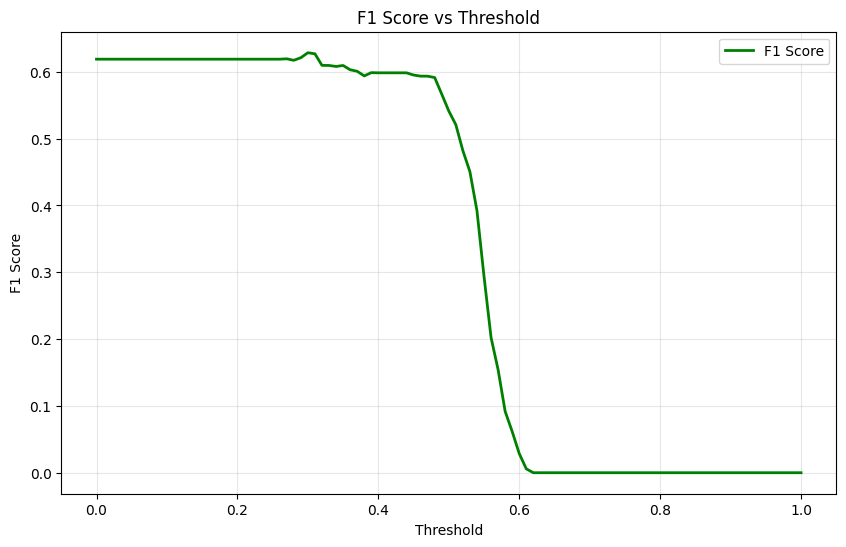

F1 is maximal at threshold: 0.30
Maximum F1 score: 0.629


(np.float64(0.3), 0.6286799620132953)

In [30]:
f1score(y_pred_lg, y_val)

In [31]:
roc_auc_score(y_val, y_pred_lg)

0.5971545054242892

#### 7.2 Parameter tuning



F1 score for c= 0.01


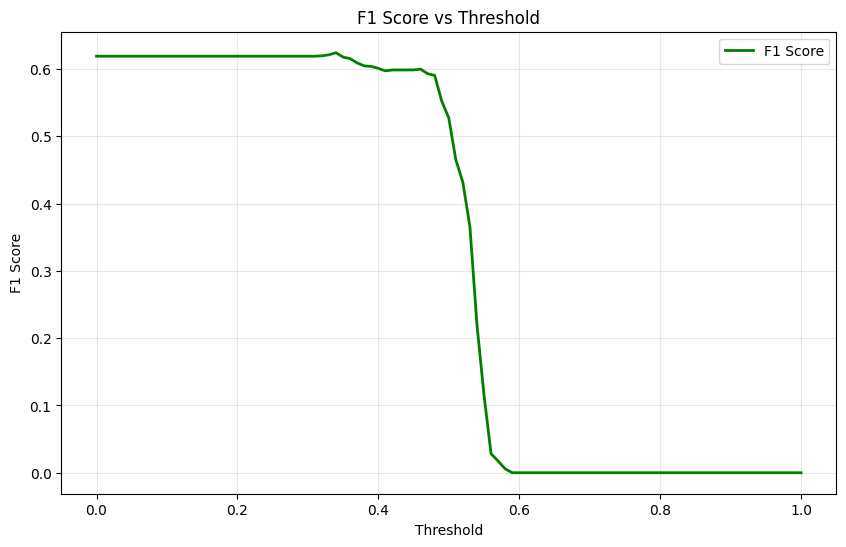

F1 is maximal at threshold: 0.34
Maximum F1 score: 0.624


F1 score for c= 0.1


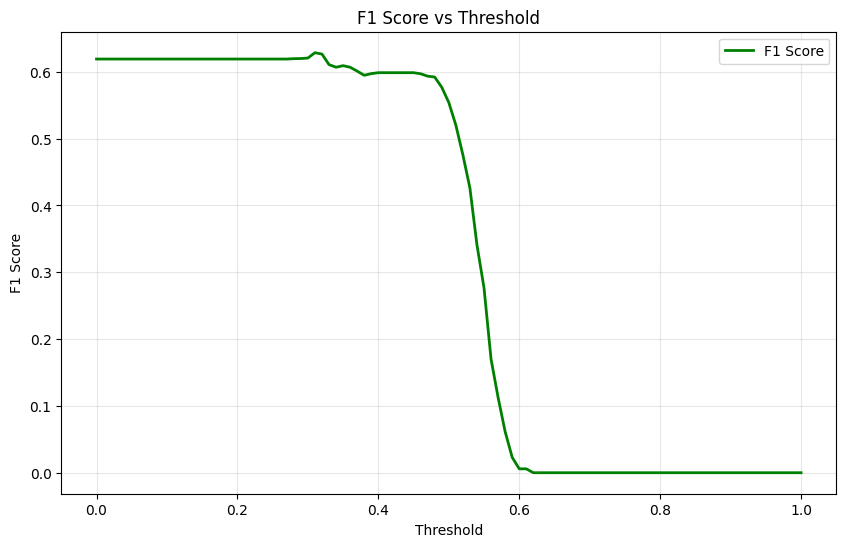

F1 is maximal at threshold: 0.31
Maximum F1 score: 0.628


F1 score for c= 1


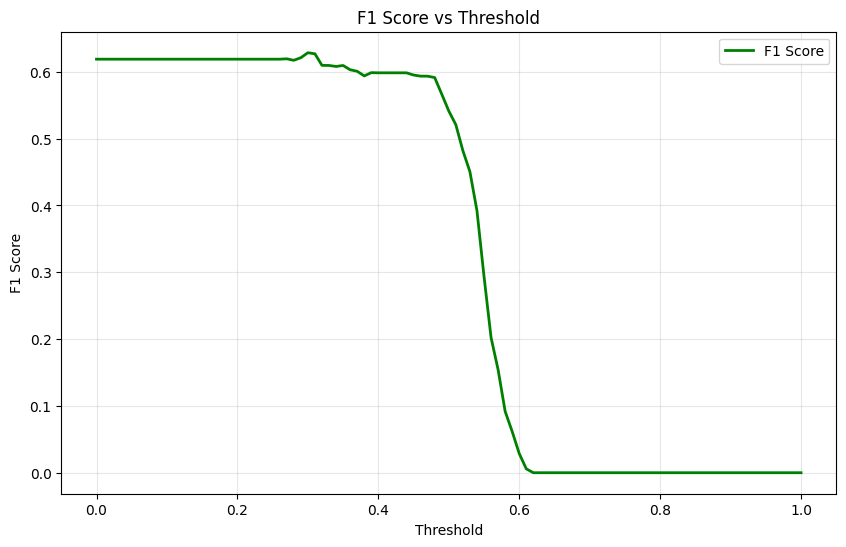

F1 is maximal at threshold: 0.30
Maximum F1 score: 0.629


F1 score for c= 10


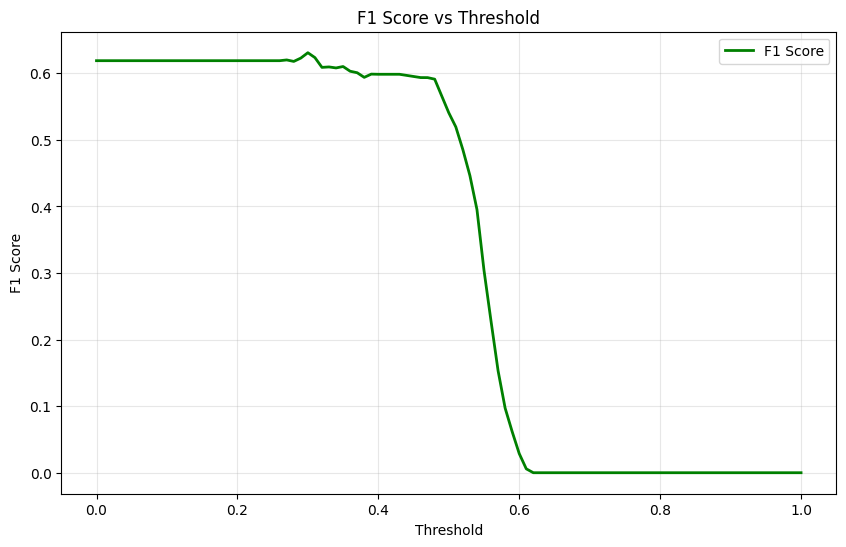

F1 is maximal at threshold: 0.30
Maximum F1 score: 0.631


F1 score for c= 100


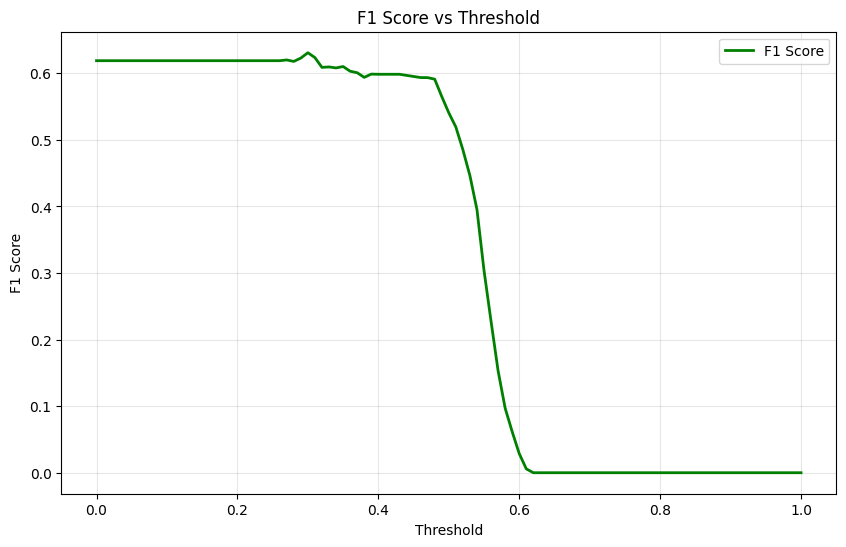

F1 is maximal at threshold: 0.30
Maximum F1 score: 0.631


F1 score summary:
0.01: (np.float64(0.34), 0.6241920590951061)
0.1: (np.float64(0.31), 0.6284622731614136)
1: (np.float64(0.3), 0.6286799620132953)
10: (np.float64(0.3), 0.6309751434034417)
100: (np.float64(0.3), 0.6309751434034417)

Accuracy:
0.01: 0.579
0.1: 0.567
1: 0.558
10: 0.557
100: 0.557

AUC:
0.01: 0.6059264352488505
0.1: 0.6002173882846467
1: 0.5971545054242892
10: 0.5969947632342932
100: 0.5968350210442972


In [32]:
accuracy_dict = {}
auc_dict = {}
f1scores = {}

# Let's try the following values of the parameter C: [0.01, 0.1, 1, 10, 100].
for c in [0.01, 0.1, 1, 10, 100]:
    
    # let's train a regularized logistic regression.
    model = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=1)
    model.fit(X_train, y_train)

    # Calculate the accuracy on the validation dataset and round it to 3 decimal digits.
    y_pred_lg = model.predict_proba(X_val)[:, 1]
    converted_decision = (y_pred_lg >= 0.5)
    accuracy = (y_val == converted_decision).mean()
    accuracy_dict[c] = round(accuracy, 3)
    auc_dict[c] = roc_auc_score(y_val, y_pred_lg)
    print("\n\nF1 score for c=", c)
    f1scores[c] = f1score(y_pred_lg, y_val)

# Print the dictionary to check the results
print("\n\nF1 score summary:")
for key, value in f1scores.items():
    print(f"{key}: {value}")

print("\nAccuracy:")
for key, value in accuracy_dict.items():
    print(f"{key}: {value}")

print("\nAUC:")
for key, value in auc_dict.items():
    print(f"{key}: {value}")

#### 7.3 Final model choice

As C increases, F1 increases slightly; however, both accuracy and AUC decrease. Therefore, I chose C=0.01 for this model

In [33]:
model = LogisticRegression(solver='liblinear', C=0.01, max_iter=1000, random_state=1)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


### 8 Decision tree

In [34]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [35]:
y_pred_dt = dt.predict_proba(X_val)[:, 1] # Getting only the first column

#### 8.1 Model evaluation

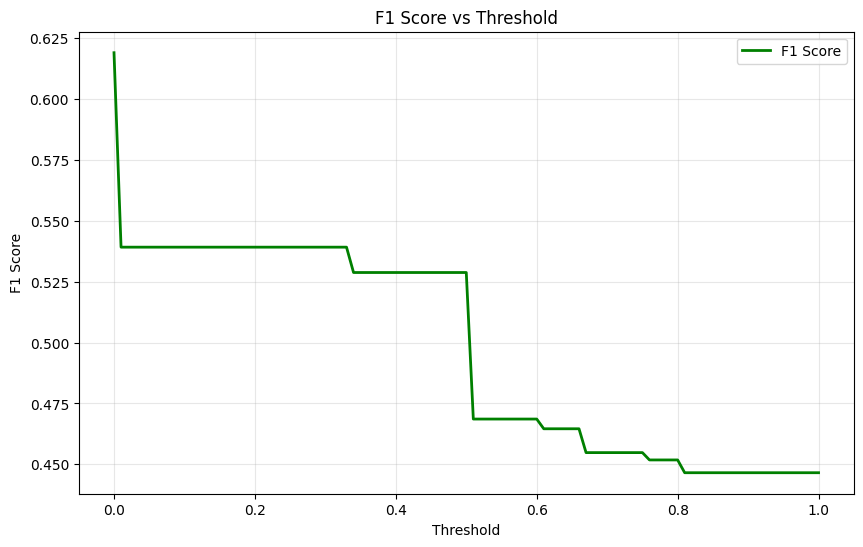

F1 is maximal at threshold: 0.00
Maximum F1 score: 0.619


(np.float64(0.0), 0.6190045248868778)

In [36]:
f1score(y_pred_dt, y_val)

In [37]:
roc_auc_score(y_val, y_pred_dt)

0.5490721062355016

In [40]:
print(export_text(dt))

|--- feature_0 <= 0.50
|   |--- feature_15 <= 0.50
|   |   |--- feature_17 <= 0.50
|   |   |   |--- feature_10 <= 3.50
|   |   |   |   |--- feature_8 <= 0.50
|   |   |   |   |   |--- feature_5 <= 0.50
|   |   |   |   |   |   |--- feature_13 <= 0.50
|   |   |   |   |   |   |   |--- class: False
|   |   |   |   |   |   |--- feature_13 >  0.50
|   |   |   |   |   |   |   |--- feature_9 <= 0.50
|   |   |   |   |   |   |   |   |--- class: True
|   |   |   |   |   |   |   |--- feature_9 >  0.50
|   |   |   |   |   |   |   |   |--- class: False
|   |   |   |   |   |--- feature_5 >  0.50
|   |   |   |   |   |   |--- class: False
|   |   |   |   |--- feature_8 >  0.50
|   |   |   |   |   |--- feature_5 <= 2.50
|   |   |   |   |   |   |--- feature_13 <= 0.50
|   |   |   |   |   |   |   |--- feature_5 <= 1.50
|   |   |   |   |   |   |   |   |--- feature_2 <= 0.50
|   |   |   |   |   |   |   |   |   |--- class: False
|   |   |   |   |   |   |   |   |--- feature_2 >  0.50
|   |   |   |   |   |   | 

#### 8.2 Parameter tuning

In [41]:
# Choosing the best depth parameter
for d in [1, 2, 3, 4, 5, 6, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train, y_train)

    y_pred_dt = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_dt)

    print('%4s -> %.3f' % (d, auc))

   1 -> 0.570
   2 -> 0.587
   3 -> 0.580
   4 -> 0.586
   5 -> 0.588
   6 -> 0.572
  10 -> 0.526
  15 -> 0.543
  20 -> 0.545
None -> 0.539


In [43]:
# Choosing the best min_samples_leaf parameter
for d in [2, 4, 5, 6]:
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
            dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
            dt.fit(X_train, y_train)
        
            y_pred_dt = dt.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, y_pred_dt)

            print('(%4s, %3d) -> %.3f' % (d, s, auc))

(   2,   1) -> 0.587
(   2,   2) -> 0.587
(   2,   5) -> 0.587
(   2,  10) -> 0.587
(   2,  15) -> 0.587
(   2,  20) -> 0.587
(   2, 100) -> 0.587
(   2, 200) -> 0.587
(   2, 500) -> 0.587
(   4,   1) -> 0.586
(   4,   2) -> 0.586
(   4,   5) -> 0.586
(   4,  10) -> 0.588
(   4,  15) -> 0.587
(   4,  20) -> 0.586
(   4, 100) -> 0.587
(   4, 200) -> 0.585
(   4, 500) -> 0.587
(   5,   1) -> 0.588
(   5,   2) -> 0.585
(   5,   5) -> 0.581
(   5,  10) -> 0.587
(   5,  15) -> 0.583
(   5,  20) -> 0.580
(   5, 100) -> 0.593
(   5, 200) -> 0.591
(   5, 500) -> 0.587
(   6,   1) -> 0.574
(   6,   2) -> 0.573
(   6,   5) -> 0.571
(   6,  10) -> 0.570
(   6,  15) -> 0.577
(   6,  20) -> 0.565
(   6, 100) -> 0.583
(   6, 200) -> 0.591
(   6, 500) -> 0.587


In [74]:
scores = []

for d in [2, 4, 5, 6]:
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
            dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
            dt.fit(X_train, y_train)
        
            y_pred_dt = dt.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, y_pred_dt)

            scores.append((d, s, auc))

columns = ['max_depths', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head(10)

,max_depths,min_samples_leaf,auc
0,2,1,0.586657
1,2,2,0.586657
2,2,5,0.586657
3,2,10,0.586657
4,2,15,0.586657
5,2,20,0.586657
6,2,100,0.586657
7,2,200,0.586806
8,2,500,0.586782
9,4,1,0.585747


In [45]:
df_scores.sort_values(by='auc', ascending=False)

,max_depths,min_samples_leaf,auc
24,5,100,0.592887
25,5,200,0.590588
34,6,200,0.590588
12,4,10,0.588240
18,5,1,0.587514
13,4,15,0.587393
15,4,100,0.587129
7,2,200,0.586806
26,5,500,0.586782
8,2,500,0.586782


In [46]:
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depths'], values=['auc'])
df_scores_pivot

auc                              
max_depths               2         4         5         6
min_samples_leaf                                        
1                 0.586657  0.585747  0.587514  0.574287
2                 0.586657  0.585747  0.585306  0.573211
5                 0.586657  0.585747  0.580684  0.570693
10                0.586657  0.588240  0.584649  0.571575
15                0.586657  0.587393  0.583299  0.576669
20                0.586657  0.586226  0.579763  0.564696
100               0.586657  0.587129  0.592887  0.583497
200               0.586806  0.584910  0.590588  0.590588
500               0.586782  0.586782  0.586782  0.586782

<Axes: xlabel='None-max_depths', ylabel='min_samples_leaf'>

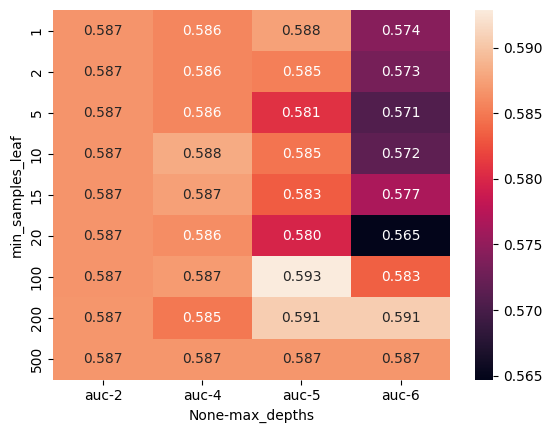

In [49]:
# Visualise as a heatmap
sns.heatmap(df_scores_pivot, annot=True, fmt='.3f')

Tuning parameters changes the accuracy slightly. Keeping max_depth=2 seems to be the most stable choice

#### 8.3 Final model choice

In [50]:
dt = DecisionTreeClassifier(max_depth=2, min_samples_leaf=500)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,500
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [52]:
# How the final tree looks like
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- age_group=13-17 <= 0.50
|   |--- class: False
|--- age_group=13-17 >  0.50
|   |--- daily_internet_hours <= 3.50
|   |   |--- class: False
|   |--- daily_internet_hours >  3.50
|   |   |--- class: True



### 9 Random forest

In [59]:
rf = RandomForestClassifier(n_estimators=10, random_state=1) # Fixing random state for the result to be reproducable
rf.fit(X_train, y_train)

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
y_pred_rt = rf.predict_proba(X_val)[:, 1]

#### 9.1 Model evaluation

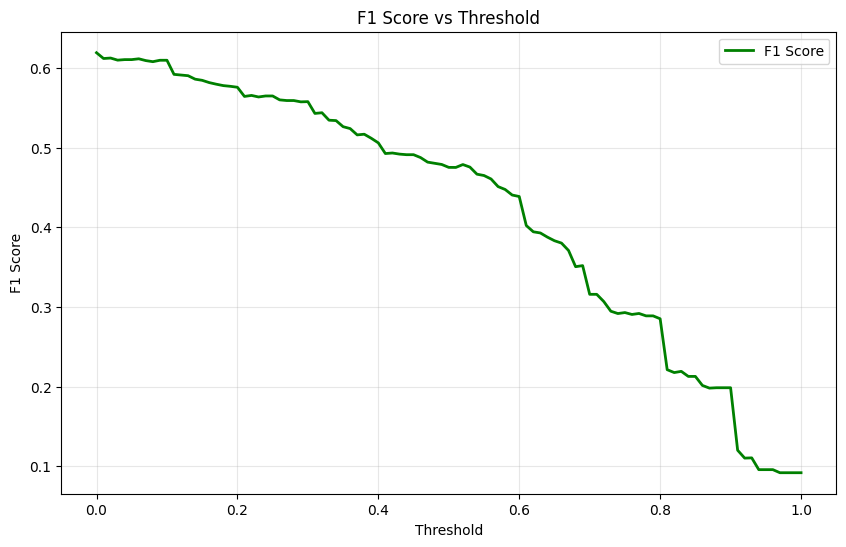

F1 is maximal at threshold: 0.00
Maximum F1 score: 0.619


(np.float64(0.0), 0.6190045248868778)

In [61]:
f1score(y_pred_rt, y_val)

In [62]:
roc_auc_score(y_val, y_pred_rt)

0.5372442388631912

#### 9.2 Parameter tuning

In [75]:
# Increasing number of estimators
scores = []

for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1) # Fixing random state for the result to be reproducable
    rf.fit(X_train, y_train)

    y_pred_rt = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_rt)
    scores.append((n, auc))

In [76]:
df_scores_rt = pd.DataFrame(scores, columns=['n_estimators', 'auc'])
df_scores_rt

,n_estimators,auc
0,10,0.537244
1,20,0.533091
2,30,0.536859
3,40,0.543186
4,50,0.543530
5,60,0.544509
6,70,0.543436
7,80,0.542682
8,90,0.545527
9,100,0.546193


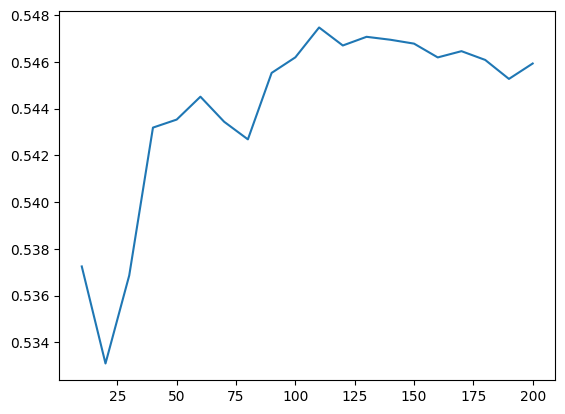

In [79]:
plt.plot(df_scores_rt.n_estimators, df_scores_rt.auc)

In [80]:
# Training for different max depth
scores = []

for d in [5, 10, 15]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=1) # Fixing random state for the result to be reproducable
        rf.fit(X_train, y_train)
    
        y_pred_rt = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred_rt)
        scores.append((d, n, auc))

In [81]:
df_scores_rt = pd.DataFrame(scores, columns=['max_depth', 'n_estimators', 'auc'])
df_scores_rt

,max_depth,n_estimators,auc
0,5,10,0.574648
1,5,20,0.580243
2,5,30,0.586615
3,5,40,0.584483
4,5,50,0.585004
5,5,60,0.587021
6,5,70,0.589938
7,5,80,0.589959
8,5,90,0.590730
9,5,100,0.590043


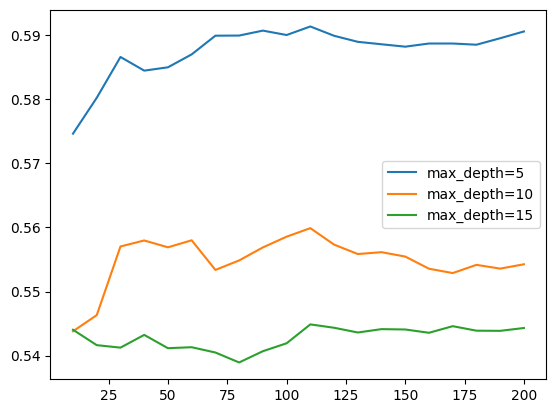

In [82]:
for d in [5, 10, 15]:
    df_subset = df_scores_rt[df_scores_rt.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.auc, label='max_depth=%d' % d)

plt.legend()

In [83]:
max_depth = 5 # It seems to be the best parameter for this model

In [84]:
# Training for different min sample leaf
scores = []

for s in [1, 3, 5, 10, 50]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=max_depth, min_samples_leaf=s, random_state=1) # Fixing random state for the result to be reproducable
        rf.fit(X_train, y_train)
    
        y_pred_rt = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred_rt)
        scores.append((s, n, auc))

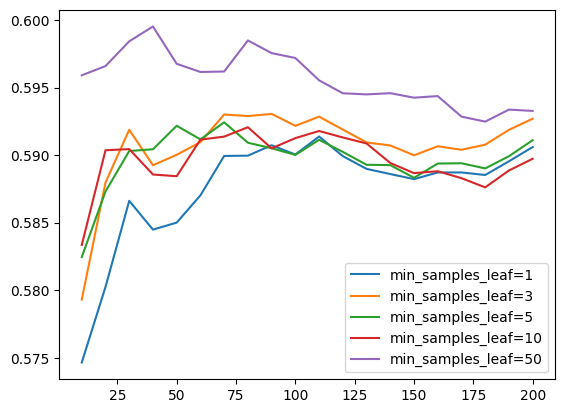

In [85]:
df_scores_rt = pd.DataFrame(scores, columns=['min_samples_leaf', 'n_estimators', 'auc'])
df_scores_rt

for s in [1, 3, 5, 10, 50]:
    df_subset = df_scores_rt[df_scores_rt.min_samples_leaf == s]
    plt.plot(df_subset.n_estimators, df_subset.auc, label='min_samples_leaf=%s' % s)

plt.legend()

In [86]:
min_samples_leaf = 50

#### 8.3 Final model choice

In [87]:
# Final random forest
rf = RandomForestClassifier(n_estimators=100,
                            max_depth=max_depth,
                            min_samples_leaf=min_samples_leaf,
                            random_state=1)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 10 XGBoost

In [90]:
features=dv.get_feature_names_out()
features=features.tolist()
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [112]:
xgb_params = {
    'eta': 1,
    'max_depth': 6,
    'min_child_weight': 1,
    'eval_metric': 'auc',
    'objective': 'binary:logistic',
    'seed': 1,
    'verbosity': 1,
}

evals_result = {}
model_xgb = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=200,
    evals=[(dtrain, 'train'), (dval, 'val')],
    evals_result=evals_result,
    verbose_eval=True
)

[0]	train-auc:0.67794	val-auc:0.56834
[1]	train-auc:0.71335	val-auc:0.57277
[2]	train-auc:0.73885	val-auc:0.56250
[3]	train-auc:0.75839	val-auc:0.56532
[4]	train-auc:0.77898	val-auc:0.55926
[5]	train-auc:0.79815	val-auc:0.55188
[6]	train-auc:0.80827	val-auc:0.54939
[7]	train-auc:0.82044	val-auc:0.54724
[8]	train-auc:0.83084	val-auc:0.53761
[9]	train-auc:0.83850	val-auc:0.53571
[10]	train-auc:0.85161	val-auc:0.53484
[11]	train-auc:0.86120	val-auc:0.52888
[12]	train-auc:0.86550	val-auc:0.53335
[13]	train-auc:0.86988	val-auc:0.53358
[14]	train-auc:0.87397	val-auc:0.53779
[15]	train-auc:0.87713	val-auc:0.53675
[16]	train-auc:0.88175	val-auc:0.52993
[17]	train-auc:0.88527	val-auc:0.53255
[18]	train-auc:0.88869	val-auc:0.52806
[19]	train-auc:0.89309	val-auc:0.52977
[20]	train-auc:0.89679	val-auc:0.52834
[21]	train-auc:0.90159	val-auc:0.52901
[22]	train-auc:0.90593	val-auc:0.52699
[23]	train-auc:0.90910	val-auc:0.52646
[24]	train-auc:0.91255	val-auc:0.52840
[25]	train-auc:0.91412	val-auc:0.52

#### 10.1 Model evaluation

In [92]:
# Test model
y_pred_xgb = model_xgb.predict(dval)

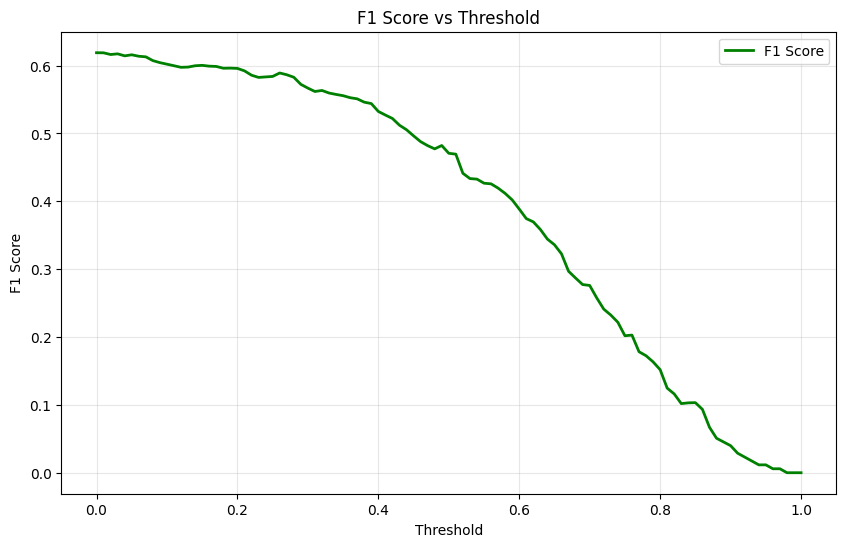

F1 is maximal at threshold: 0.00
Maximum F1 score: 0.619


(np.float64(0.0), 0.6190045248868778)

In [96]:
f1score(y_pred_xgb, y_val)

In [93]:
roc_auc_score(y_val, y_pred_xgb)

0.5438978483421539

#### 10.2 Parameter tuning

In [97]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

model = xgb.train(xgb_params, dtrain, num_boost_round=200, verbose_eval=5, evals=watchlist)

[0]	train-auc:0.67794	val-auc:0.56834
[5]	train-auc:0.70995	val-auc:0.57656
[10]	train-auc:0.72167	val-auc:0.57485
[15]	train-auc:0.73185	val-auc:0.57165
[20]	train-auc:0.74085	val-auc:0.56612
[25]	train-auc:0.75270	val-auc:0.56509
[30]	train-auc:0.76423	val-auc:0.56471
[35]	train-auc:0.77390	val-auc:0.56359
[40]	train-auc:0.78384	val-auc:0.56072
[45]	train-auc:0.79599	val-auc:0.56120
[50]	train-auc:0.80783	val-auc:0.55896
[55]	train-auc:0.81635	val-auc:0.55439
[60]	train-auc:0.82354	val-auc:0.55352
[65]	train-auc:0.82961	val-auc:0.55247
[70]	train-auc:0.83572	val-auc:0.55273
[75]	train-auc:0.84329	val-auc:0.55082
[80]	train-auc:0.84778	val-auc:0.55108
[85]	train-auc:0.85266	val-auc:0.55017
[90]	train-auc:0.85574	val-auc:0.54838
[95]	train-auc:0.85888	val-auc:0.54887
[100]	train-auc:0.86209	val-auc:0.54884
[105]	train-auc:0.86547	val-auc:0.54877
[110]	train-auc:0.86875	val-auc:0.55029
[115]	train-auc:0.87332	val-auc:0.55157
[120]	train-auc:0.87603	val-auc:0.55013
[125]	train-auc:0.8795

In [98]:
def parse_xg_output():
    results = []

    df_results = pd.DataFrame({
        'num_iter': range(len(evals_result['train']['auc'])),
        'train_auc': evals_result['train']['auc'],
        'val_auc': evals_result['val']['auc']
    })
    return df_results

In [99]:
df_score_x = parse_xg_output()
df_score_x

,num_iter,train_auc,val_auc
0,0,0.677937,0.568338
1,1,0.698908,0.573002
2,2,0.702896,0.578454
3,3,0.703262,0.576881
4,4,0.707346,0.571790
...,...,...,...
195,195,0.907955,0.544127
196,196,0.908334,0.544294
197,197,0.908602,0.544016
198,198,0.908952,0.543940


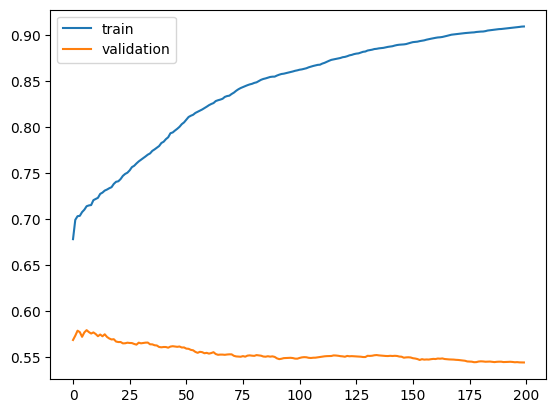

In [101]:
plt.plot(df_score_x.num_iter, df_score_x.train_auc, label='train')
plt.plot(df_score_x.num_iter, df_score_x.val_auc, label='validation')
plt.legend()

In [102]:
scores = {}

In [113]:
# Tuning eta
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xg_output()
scores

{'eta=0.1':      num_iter  train_auc   val_auc
 0           0   0.677937  0.568338
 1           1   0.698908  0.573002
 2           2   0.702896  0.578454
 3           3   0.703262  0.576881
 4           4   0.707346  0.571790
 ..        ...        ...       ...
 195       195   0.907955  0.544127
 196       196   0.908334  0.544294
 197       197   0.908602  0.544016
 198       198   0.908952  0.543940
 199       199   0.909087  0.543898
 
 [200 rows x 3 columns],
 'eta=0.01':      num_iter  train_auc   val_auc
 0           0   0.677937  0.568338
 1           1   0.697959  0.572405
 2           2   0.696395  0.573099
 3           3   0.694473  0.572388
 4           4   0.697653  0.575256
 ..        ...        ...       ...
 195       195   0.737676  0.570217
 196       196   0.737764  0.570252
 197       197   0.738104  0.570349
 198       198   0.738281  0.570162
 199       199   0.738576  0.570432
 
 [200 rows x 3 columns],
 'eta=0.05':      num_iter  train_auc   val_auc
 0         

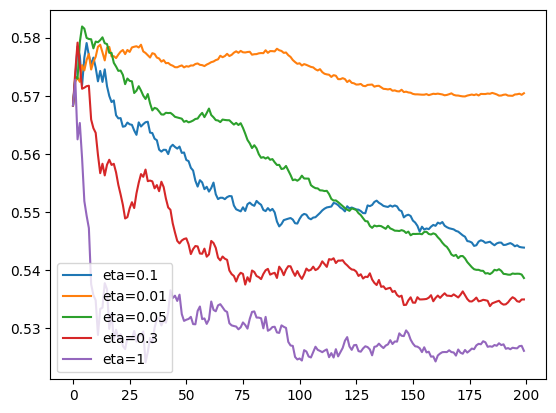

In [114]:
for key, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=key)
plt.legend()

ETA = 0.01

In [115]:
scores = {}

In [122]:
xgb_params = {
    'eta': 0.01,
    'max_depth': 10,
    'min_child_weight': 1,
    'eval_metric': 'auc',
    'objective': 'binary:logistic',
    'seed': 1,
    'verbosity': 1,
}

evals_result = {}
model_xgb = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=200,
    evals=[(dtrain, 'train'), (dval, 'val')],
    evals_result=evals_result,
    verbose_eval=True
)

[0]	train-auc:0.77169	val-auc:0.54197
[1]	train-auc:0.77363	val-auc:0.53912
[2]	train-auc:0.77457	val-auc:0.53960
[3]	train-auc:0.77620	val-auc:0.54492
[4]	train-auc:0.77722	val-auc:0.54476
[5]	train-auc:0.77856	val-auc:0.54471
[6]	train-auc:0.79110	val-auc:0.54647
[7]	train-auc:0.79786	val-auc:0.54823
[8]	train-auc:0.80181	val-auc:0.54943
[9]	train-auc:0.80378	val-auc:0.55159
[10]	train-auc:0.80441	val-auc:0.55197
[11]	train-auc:0.80474	val-auc:0.55238
[12]	train-auc:0.80459	val-auc:0.55251
[13]	train-auc:0.80460	val-auc:0.55301
[14]	train-auc:0.80435	val-auc:0.55295
[15]	train-auc:0.80409	val-auc:0.55225
[16]	train-auc:0.80370	val-auc:0.55148
[17]	train-auc:0.80327	val-auc:0.55109
[18]	train-auc:0.80400	val-auc:0.55086
[19]	train-auc:0.80436	val-auc:0.55078
[20]	train-auc:0.80374	val-auc:0.55047
[21]	train-auc:0.80438	val-auc:0.55008
[22]	train-auc:0.80446	val-auc:0.54879
[23]	train-auc:0.80476	val-auc:0.54843
[24]	train-auc:0.80481	val-auc:0.54791
[25]	train-auc:0.80497	val-auc:0.54

In [123]:
# Tuning max depth 3, 4, 6, 10
key = 'max_depth=%s' % (xgb_params['max_depth'])
scores[key] = parse_xg_output()
scores

{'max_depth=6':      num_iter  train_auc   val_auc
 0           0   0.677937  0.568338
 1           1   0.697959  0.572405
 2           2   0.696395  0.573099
 3           3   0.694473  0.572388
 4           4   0.697653  0.575256
 ..        ...        ...       ...
 195       195   0.737676  0.570217
 196       196   0.737764  0.570252
 197       197   0.738104  0.570349
 198       198   0.738281  0.570162
 199       199   0.738576  0.570432
 
 [200 rows x 3 columns],
 'max_depth=3':      num_iter  train_auc   val_auc
 0           0   0.620254  0.580382
 1           1   0.627749  0.576996
 2           2   0.625066  0.574218
 3           3   0.627749  0.576996
 4           4   0.627971  0.577447
 ..        ...        ...       ...
 195       195   0.638694  0.580645
 196       196   0.638694  0.580736
 197       197   0.638799  0.580389
 198       198   0.638931  0.580354
 199       199   0.638992  0.580347
 
 [200 rows x 3 columns],
 'max_depth=4':      num_iter  train_auc   val_auc
 

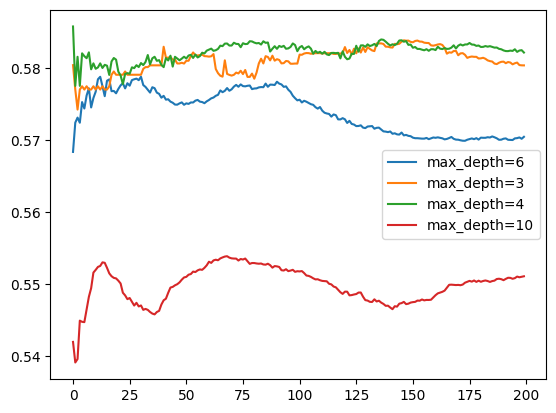

In [124]:
for max_depth, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=max_depth)
plt.legend()

Max_depth = 4

In [125]:
scores = {}

In [132]:
xgb_params = {
    'eta': 0.01,
    'max_depth': 4,
    'min_child_weight': 30,
    'eval_metric': 'auc',
    'objective': 'binary:logistic',
    'seed': 1,
    'verbosity': 1,
}

evals_result = {}
model_xgb = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=200,
    evals=[(dtrain, 'train'), (dval, 'val')],
    evals_result=evals_result,
    verbose_eval=True
)

[0]	train-auc:0.62235	val-auc:0.59091
[1]	train-auc:0.62874	val-auc:0.57954
[2]	train-auc:0.62775	val-auc:0.58389
[3]	train-auc:0.62874	val-auc:0.57954
[4]	train-auc:0.62798	val-auc:0.57421
[5]	train-auc:0.62874	val-auc:0.57954
[6]	train-auc:0.62875	val-auc:0.57586
[7]	train-auc:0.62874	val-auc:0.57954
[8]	train-auc:0.62882	val-auc:0.57688
[9]	train-auc:0.62874	val-auc:0.57954
[10]	train-auc:0.62885	val-auc:0.57650
[11]	train-auc:0.62874	val-auc:0.57954
[12]	train-auc:0.62906	val-auc:0.57711
[13]	train-auc:0.62874	val-auc:0.57954
[14]	train-auc:0.62898	val-auc:0.57705
[15]	train-auc:0.62874	val-auc:0.57954
[16]	train-auc:0.62887	val-auc:0.57728
[17]	train-auc:0.62874	val-auc:0.57954
[18]	train-auc:0.62887	val-auc:0.57728
[19]	train-auc:0.62882	val-auc:0.57688
[20]	train-auc:0.62887	val-auc:0.57728
[21]	train-auc:0.62885	val-auc:0.57650
[22]	train-auc:0.62898	val-auc:0.57761
[23]	train-auc:0.62906	val-auc:0.57711
[24]	train-auc:0.62842	val-auc:0.57786
[25]	train-auc:0.62898	val-auc:0.57

In [133]:
# Tuning min_child_weight 1, 10, 30
key = 'min_child_weight=%s' % (xgb_params['min_child_weight'])
scores[key] = parse_xg_output()
scores

{'min_child_weight=1':      num_iter  train_auc   val_auc
 0           0   0.631312  0.585747
 1           1   0.639416  0.577506
 2           2   0.637968  0.581541
 3           3   0.639416  0.577506
 4           4   0.638518  0.582021
 ..        ...        ...       ...
 195       195   0.667623  0.582583
 196       196   0.667685  0.582222
 197       197   0.667903  0.582410
 198       198   0.668052  0.582458
 199       199   0.668099  0.582132
 
 [200 rows x 3 columns],
 'min_child_weight=10':      num_iter  train_auc   val_auc
 0           0   0.628189  0.582496
 1           1   0.636903  0.577284
 2           2   0.635047  0.580444
 3           3   0.636903  0.577284
 4           4   0.636115  0.580316
 ..        ...        ...       ...
 195       195   0.655022  0.581937
 196       196   0.655249  0.582139
 197       197   0.655250  0.582111
 198       198   0.655394  0.582208
 199       199   0.655507  0.582007
 
 [200 rows x 3 columns],
 'min_child_weight=30':      num_iter

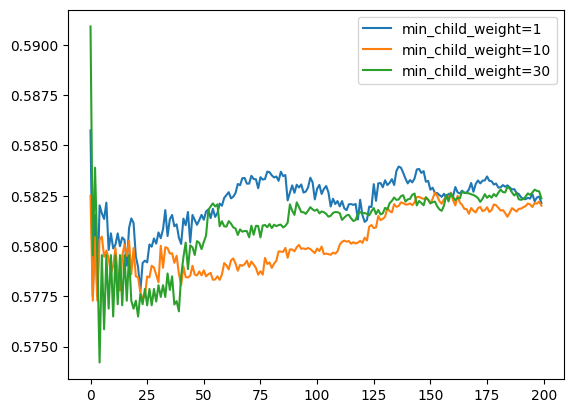

In [134]:
for min_child_weight, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=min_child_weight)
plt.legend()

Min_child_weight = 1

Results:
- best ETA: 0.01
- best max_depth: 4
- best min_child_weight: 1

#### 8.3 Final model choice

In [136]:
xgb_params = {
    'eta': 0.01,
    'max_depth': 4,
    'min_child_weight': 1,
    'eval_metric': 'auc',
    'objective': 'binary:logistic',
    'seed': 1,
    'verbosity': 1,
}

evals_result = {}
model_xgb = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=200,
    evals=[(dtrain, 'train'), (dval, 'val')],
    evals_result=evals_result,
    verbose_eval=True
)

[0]	train-auc:0.63131	val-auc:0.58575
[1]	train-auc:0.63942	val-auc:0.57751
[2]	train-auc:0.63797	val-auc:0.58154
[3]	train-auc:0.63942	val-auc:0.57751
[4]	train-auc:0.63852	val-auc:0.58202
[5]	train-auc:0.63801	val-auc:0.58162
[6]	train-auc:0.63826	val-auc:0.58134
[7]	train-auc:0.63834	val-auc:0.58216
[8]	train-auc:0.63893	val-auc:0.57980
[9]	train-auc:0.63870	val-auc:0.58063
[10]	train-auc:0.63885	val-auc:0.57988
[11]	train-auc:0.63916	val-auc:0.58007
[12]	train-auc:0.63872	val-auc:0.58063
[13]	train-auc:0.63907	val-auc:0.57999
[14]	train-auc:0.63946	val-auc:0.58042
[15]	train-auc:0.63969	val-auc:0.58031
[16]	train-auc:0.64064	val-auc:0.57902
[17]	train-auc:0.64067	val-auc:0.58089
[18]	train-auc:0.64062	val-auc:0.58137
[19]	train-auc:0.64087	val-auc:0.58114
[20]	train-auc:0.64131	val-auc:0.57948
[21]	train-auc:0.64161	val-auc:0.57895
[22]	train-auc:0.64228	val-auc:0.57775
[23]	train-auc:0.64139	val-auc:0.57916
[24]	train-auc:0.64176	val-auc:0.57927
[25]	train-auc:0.64144	val-auc:0.57

### 11 Selecting the best model for predicting cyber bullying

#### Logistic regression results

In [141]:
roc_auc_score(y_val, y_pred_lg)

0.5968350210442972

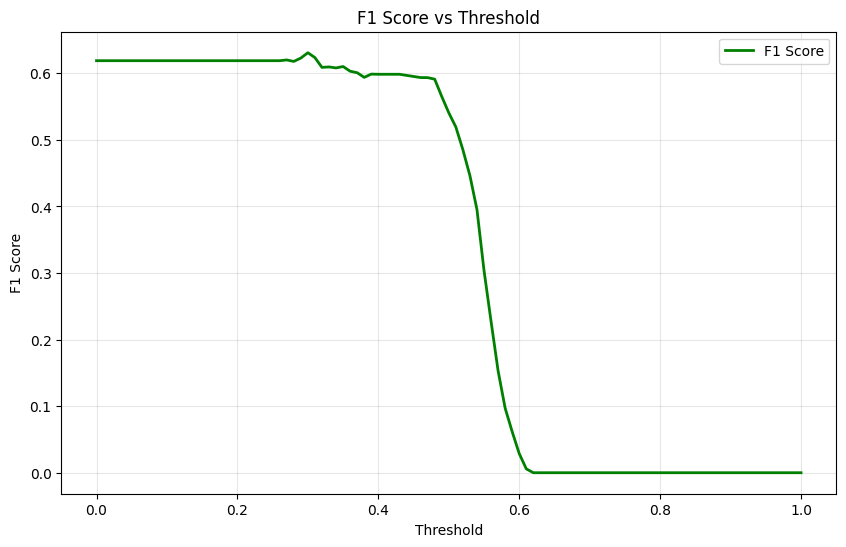

F1 is maximal at threshold: 0.30
Maximum F1 score: 0.631


(np.float64(0.3), 0.6309751434034417)

In [140]:
f1score(y_pred_lg, y_val)

#### Decision tree results

In [143]:
roc_auc_score(y_val, y_pred_dt)

0.5867816810434637

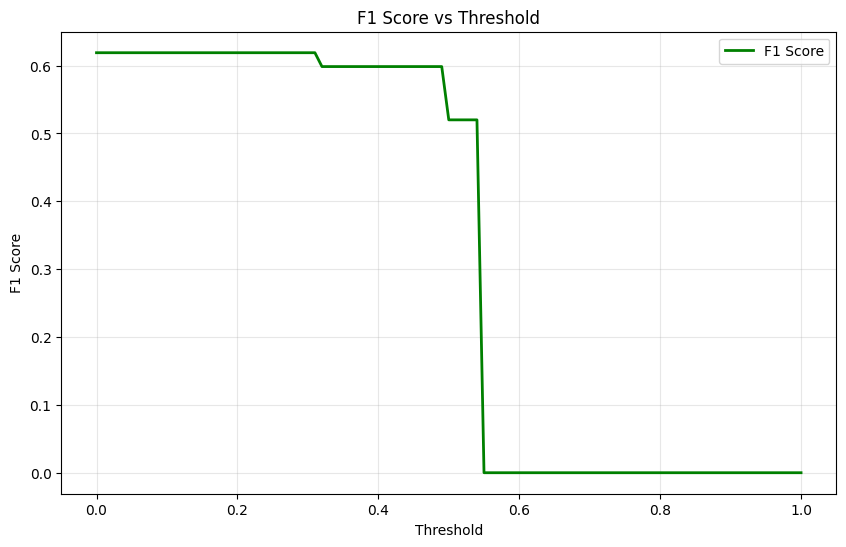

F1 is maximal at threshold: 0.00
Maximum F1 score: 0.619


(np.float64(0.0), 0.6190045248868778)

In [144]:
f1score(y_pred_dt, y_val)

#### Random forest results

In [145]:
roc_auc_score(y_val, y_pred_rt)

0.5932720756761262

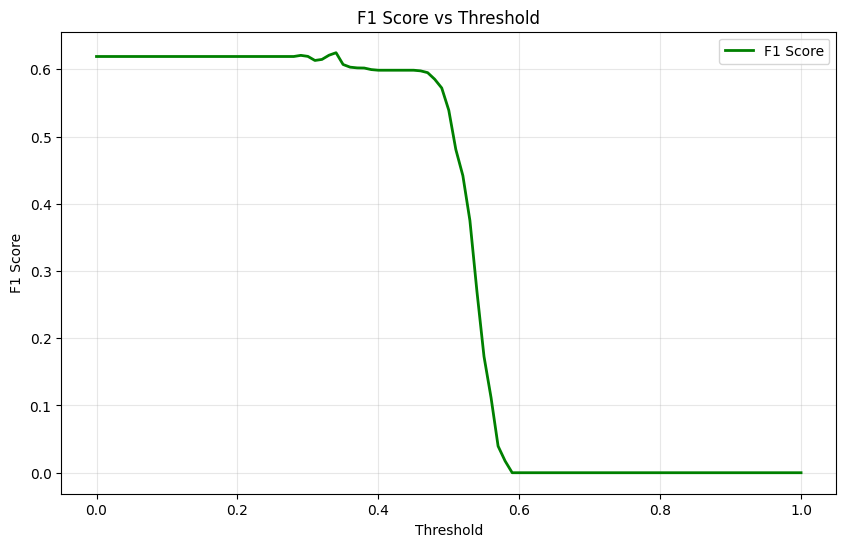

F1 is maximal at threshold: 0.34
Maximum F1 score: 0.625


(np.float64(0.34), 0.624618514750763)

In [146]:
f1score(y_pred_rt, y_val)

#### XGBoost results

In [147]:
y_pred_x = model_xgb.predict(dval)

In [148]:
roc_auc_score(y_val, y_pred_x)

0.5821317942520592

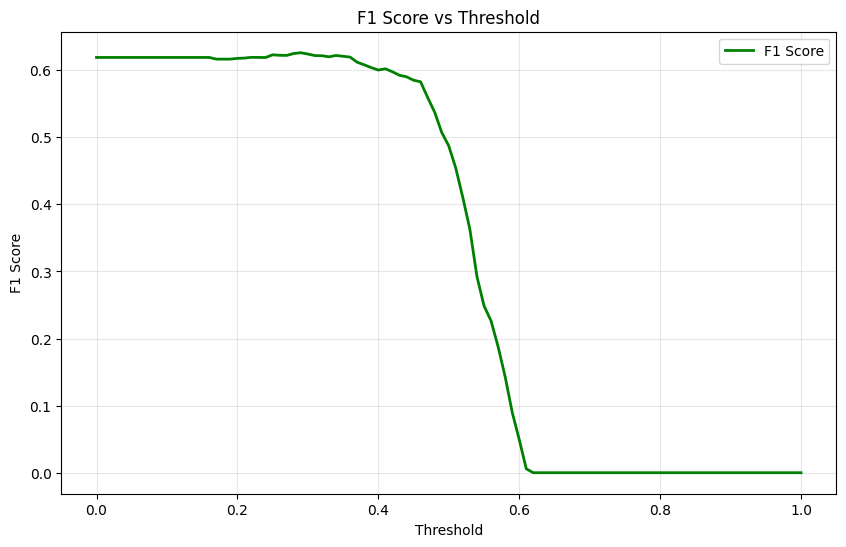

F1 is maximal at threshold: 0.29
Maximum F1 score: 0.626


(np.float64(0.29), 0.6260543580131209)

In [149]:
f1score(y_pred_x, y_val)